In [1]:
import random
import os
import numpy as np
import torch

def seed_everything(seed=42):

    random.seed(seed)                     # Python random
    np.random.seed(seed)                  # NumPy random

    torch.manual_seed(seed)               # PyTorch CPU
    torch.cuda.manual_seed_all(seed)      # PyTorch GPU

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    os.environ["PYTHONHASHSEED"] = str(seed)

seed_everything(42)

In [2]:
import pandas as pd
df_all= pd.read_csv(r"all_india_rail_final.csv",low_memory=False)
import scipy.integrate as integrate

if not hasattr(integrate, "simps") and hasattr(integrate, "simpson"):
    integrate.simps = integrate.simpson
df_all.shape

(2722669, 21)

In [3]:
df_ncr = df_all[df_all["RLYCODE"].astype(str).str.strip().str.upper() == "NCR"]

print(df_ncr.shape)


(127541, 21)


In [4]:
df_ncr = df_ncr[df_ncr["Weather_failed"].astype(str).str.strip().str.upper() == "0"]

print(df_ncr.shape)
df_ncr.sample(5)

(126969, 21)


,RLYCODE,DIVCODE,SECTION,LINE,RAIL_SECTION,ANNUAL_GMT,SPEED,GMTCARRIED,LRRR,AXLELOAD,...,STRAIGHT_CURVE,SERVICE_LIFE,LAYINGDATE.1,USFD_CLASSIFICATION,KMTO,METTO,DURATION,Weather_failed,Censoring_date,FRACTURE_DATE.1
609261,NCR,AGRA,DHO - BHA,DN,60KG,65.160,130.0,215.0,RR,22.9,...,CURVE,1000,2021-09-01,GR,1332,411.57,1498.0,0,2025-10-08,NaN
711129,NCR,PRYJ,PNK--ETW,UP,60KG,88.110,130.0,223.0,RR,22.32,...,STRAIGHT,1000,2021-12-01,GR,1055,679.50,1407.0,0,2025-10-08,NaN
698244,NCR,PRYJ,KRJ-GZB,IIIRD LINE,60KG,28.200,130.0,72.0,RR,22.32,...,CURVE,800,2021-02-01,GR,1383,473.70,1710.0,0,2025-10-08,NaN
691489,NCR,PRYJ,ETW-SKB,UP,60KG,65.440,130.0,353.0,RR,22.32,...,STRAIGHT,1000,2020-01-01,GR,1189,540.64,2107.0,0,2025-10-08,NaN
717574,NCR,PRYJ,PRYJ-CNBI,UP,60KG,45.961,130.0,95.0,LR,22.32,...,STRAIGHT,1000,2023-06-01,GR,847,272.18,860.0,0,2025-10-08,NaN


In [5]:
df_ncr['SECTION'].value_counts()

SECTION
PRYJ-CNBI                9338
MTJ-OKA                  8916
KRJ-GZB                  7052
PNK--ETW                 5701
CAR - COI                5483
                         ... 
PRG-PRYJ                   55
BNPR - OHAN                46
HRS HRF                    44
GWL SOE                    12
AGD - MAKR CHORD LINE      10
Name: count, Length: 77, dtype: int64

In [6]:
pd.set_option('display.max_columns', None)
df_ncr.isnull().sum().to_frame('Null Count').T

,RLYCODE,DIVCODE,SECTION,LINE,RAIL_SECTION,ANNUAL_GMT,SPEED,GMTCARRIED,LRRR,AXLELOAD,TRACK_TYPE,STRAIGHT_CURVE,SERVICE_LIFE,LAYINGDATE.1,USFD_CLASSIFICATION,KMTO,METTO,DURATION,Weather_failed,Censoring_date,FRACTURE_DATE.1
Null Count,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,126969


In [7]:
cols_to_drop = ['RLYCODE']
df_ncr = df_ncr.drop(columns=cols_to_drop, errors='ignore')

In [8]:
df_ncr.DIVCODE.unique()

array(['AGRA', 'JHS', 'PRYJ'], dtype=object)

In [9]:
df_ncr.isnull().sum()

DIVCODE                     0
SECTION                     0
LINE                        0
RAIL_SECTION                0
ANNUAL_GMT                  0
SPEED                       0
GMTCARRIED                  0
LRRR                        0
AXLELOAD                    0
TRACK_TYPE                  0
STRAIGHT_CURVE              0
SERVICE_LIFE                0
LAYINGDATE.1                0
USFD_CLASSIFICATION         0
KMTO                        0
METTO                       0
DURATION                    0
Weather_failed              0
Censoring_date              0
FRACTURE_DATE.1        126969
dtype: int64

In [10]:
df_ncr = df_ncr[df_ncr.DURATION>0]

In [11]:
p75 = df_ncr['DURATION'].quantile(0.75)
print("75th Percentile:", p75)
p25 = df_ncr['DURATION'].quantile(0.25)
print("25th Percentile:", p25)
iqr = 1.5 *(p75-p25)
print("Upper limit:", p75 + iqr)


75th Percentile: 3477.0
25th Percentile: 891.0
Upper limit: 7356.0


In [12]:
df_ncr.DURATION.describe()

count    126969.000000
mean       2306.544976
std        1836.241294
min           7.000000
25%         891.000000
50%        1802.000000
75%        3477.000000
max       22895.000000
Name: DURATION, dtype: float64

In [13]:

upper = p75 + iqr
df_ncr = df_ncr[df_ncr.DURATION <= upper]

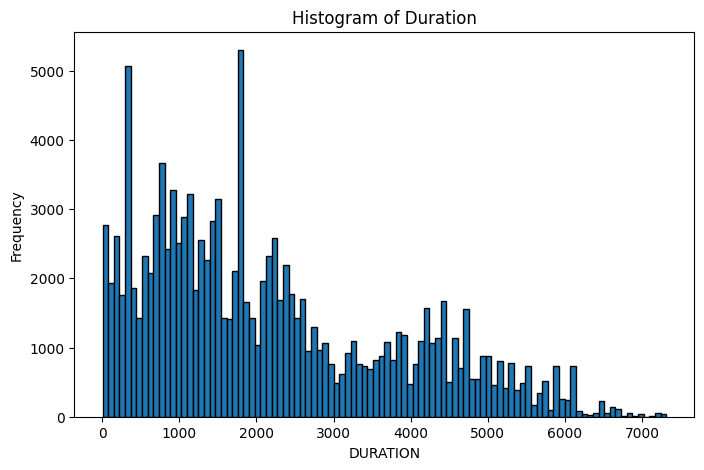

In [14]:
import matplotlib.pyplot as plt

# assuming df is your DataFrame
plt.figure(figsize=(8,5))
plt.hist(df_ncr["DURATION"], bins=100, edgecolor="black")
plt.xlabel("DURATION")
plt.ylabel("Frequency")
plt.title("Histogram of Duration")
plt.show()

Failure dataset 

In [15]:
df_failure = df_all[df_all["RLYCODE"].astype(str).str.strip().str.upper() == "NCR"]

print(df_failure.shape)

(127541, 21)


In [16]:
df_failure = df_failure[df_failure["Weather_failed"].astype(str).str.strip().str.upper() == "1"]

print(df_failure.shape)
df_failure.sample(5)

(572, 21)


,RLYCODE,DIVCODE,SECTION,LINE,RAIL_SECTION,ANNUAL_GMT,SPEED,GMTCARRIED,LRRR,AXLELOAD,TRACK_TYPE,STRAIGHT_CURVE,SERVICE_LIFE,LAYINGDATE.1,USFD_CLASSIFICATION,KMTO,METTO,DURATION,Weather_failed,Censoring_date,FRACTURE_DATE.1
2714316,NCR,AGRA,BTE-BKI,SL,52KG,28.034,110.0,383.84,RR,22.9,LWR,STRAIGHT,525,2015-01-09,GR,82,437.0,2918.0,1,NaN,2023-01-05
2717579,NCR,PRYJ,DDU-CAR,DN,60KG,35.133,130.0,786.00,RR,22.32,LWR,STRAIGHT,800,2011-01-03,GR,697,166.0,5096.0,1,NaN,2024-12-16
2713781,NCR,PRYJ,MKP LINK Jn,DN,60KG,33.480,110.0,365.43,LR,22.32,LWR,STRAIGHT,800,2016-01-07,GR,1260,73.0,2132.0,1,NaN,2021-11-08
2716019,NCR,PRYJ,PNK--ETW,DN,60KG,76.940,130.0,685.15,RR,22.32,LWR,STRAIGHT,800,2011-01-05,GR,1148,186.0,4335.0,1,NaN,2022-11-18
2717755,NCR,PRYJ,BRN ETH,SL,52KG,2.800,75.0,567.15,LR,22.32,LWR,STRAIGHT,350,2006-01-01,GR,46,653.0,5129.0,1,NaN,2020-01-17


In [17]:
len(df_failure.SECTION.unique())

57

In [18]:
df_failure[df_failure.DURATION ==0].describe()

,ANNUAL_GMT,SPEED,GMTCARRIED,SERVICE_LIFE,KMTO,METTO,DURATION,Weather_failed
count,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
max,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [19]:
df_failure.DURATION.describe()

count      572.000000
mean      3030.858392
std       2111.822431
min          2.000000
25%       1104.750000
50%       3280.500000
75%       4369.750000
max      17919.000000
Name: DURATION, dtype: float64

In [20]:
p75 = df_failure['DURATION'].quantile(0.75)
print("75th Percentile:", p75)
p25 = df_failure['DURATION'].quantile(0.25)
print("25th Percentile:", p25)
iqr = 1.5*(p75-p25)
print("Upper limit:", p75 + iqr)

75th Percentile: 4369.75
25th Percentile: 1104.75
Upper limit: 9267.25


In [21]:
upper = p75 + iqr
df_failure[df_failure.DURATION ==0]

,RLYCODE,DIVCODE,SECTION,LINE,RAIL_SECTION,ANNUAL_GMT,SPEED,GMTCARRIED,LRRR,AXLELOAD,TRACK_TYPE,STRAIGHT_CURVE,SERVICE_LIFE,LAYINGDATE.1,USFD_CLASSIFICATION,KMTO,METTO,DURATION,Weather_failed,Censoring_date,FRACTURE_DATE.1


In [22]:
df_failure = df_failure[df_failure.DURATION <= upper]

In [23]:
df_failure.DURATION.describe()

count     567.000000
mean     2948.619048
std      1911.637690
min         2.000000
25%      1099.500000
50%      3272.000000
75%      4353.500000
max      8431.000000
Name: DURATION, dtype: float64

In [24]:
df_failure = df_failure.rename(columns={'FRACTURE_DATE.1': 'FRACTURE_DATE'})

In [25]:
df_failure.FRACTURE_DATE.max()

'2025-10-11'

In [26]:
df_failure.isnull().sum()

RLYCODE                  0
DIVCODE                  0
SECTION                  0
LINE                     0
RAIL_SECTION             0
ANNUAL_GMT              21
SPEED                    0
GMTCARRIED               5
LRRR                     0
AXLELOAD                 0
TRACK_TYPE               0
STRAIGHT_CURVE           0
SERVICE_LIFE             0
LAYINGDATE.1             0
USFD_CLASSIFICATION      0
KMTO                     0
METTO                    0
DURATION                 0
Weather_failed           0
Censoring_date         567
FRACTURE_DATE            0
dtype: int64

In [27]:
df_ncr.columns

Index(['DIVCODE', 'SECTION', 'LINE', 'RAIL_SECTION', 'ANNUAL_GMT', 'SPEED',
       'GMTCARRIED', 'LRRR', 'AXLELOAD', 'TRACK_TYPE', 'STRAIGHT_CURVE',
       'SERVICE_LIFE', 'LAYINGDATE.1', 'USFD_CLASSIFICATION', 'KMTO', 'METTO',
       'DURATION', 'Weather_failed', 'Censoring_date', 'FRACTURE_DATE.1'],
      dtype='object')

In [28]:
df_failure.columns

Index(['RLYCODE', 'DIVCODE', 'SECTION', 'LINE', 'RAIL_SECTION', 'ANNUAL_GMT',
       'SPEED', 'GMTCARRIED', 'LRRR', 'AXLELOAD', 'TRACK_TYPE',
       'STRAIGHT_CURVE', 'SERVICE_LIFE', 'LAYINGDATE.1', 'USFD_CLASSIFICATION',
       'KMTO', 'METTO', 'DURATION', 'Weather_failed', 'Censoring_date',
       'FRACTURE_DATE'],
      dtype='object')

In [29]:
df = df_all[df_all["RLYCODE"].astype(str).str.strip().str.upper() == "NCR"]

print(df.shape)
df.sample(5)

(127541, 21)


,RLYCODE,DIVCODE,SECTION,LINE,RAIL_SECTION,ANNUAL_GMT,SPEED,GMTCARRIED,LRRR,AXLELOAD,TRACK_TYPE,STRAIGHT_CURVE,SERVICE_LIFE,LAYINGDATE.1,USFD_CLASSIFICATION,KMTO,METTO,DURATION,Weather_failed,Censoring_date,FRACTURE_DATE.1
710204,NCR,PRYJ,PNK--ETW,UP,60KG,65.440,130.0,368.0,LR,22.32,LWR,STRAIGHT,1000,2019-12-01,GR,1095,173.5,2138.0,0,2025-10-08,NaN
705878,NCR,PRYJ,NYN-PRYJ,DN,60KG,35.805,130.0,263.0,RR,22.32,LWR,STRAIGHT,800,2023-05-01,GR,825,355.5,891.0,0,2025-10-08,NaN
651640,NCR,JHS,JHS GWL,DN,60KG,60.100,130.0,282.0,RR,22.32,LWR,STRAIGHT,1000,2020-09-01,GR,1152,514.5,1863.0,0,2025-10-08,NaN
627169,NCR,AGRA,MTJ-OKA,IVTH LINE,60KG,77.760,160.0,86.0,RR,22.9,LWR,STRAIGHT,800,2019-01-01,GR,1465,500.0,2472.0,0,2025-10-08,NaN
648323,NCR,JHS,JHS AIT,DN,60KG,19.680,110.0,125.0,RR,22.32,LWR,STRAIGHT,800,2010-07-01,GR,1140,945.4,5578.0,0,2025-10-08,NaN


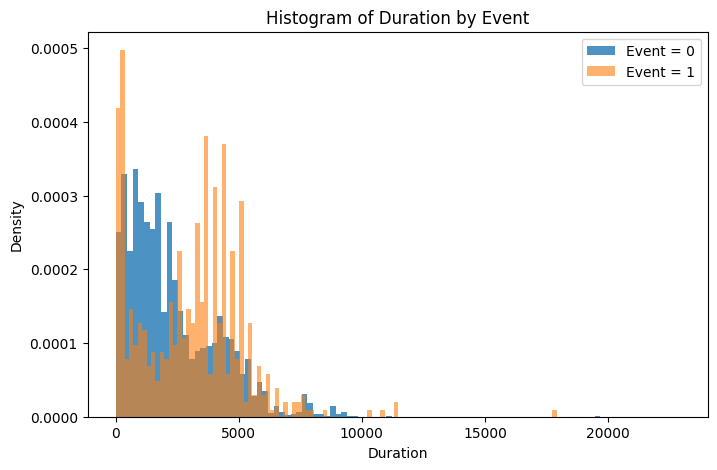

In [30]:
plt.figure(figsize=(8,5))

plt.hist(df[df["Weather_failed"] == 0]["DURATION"], 
         bins=100, alpha=0.8, density=True, label="Event = 0")

plt.hist(df[df["Weather_failed"] == 1]["DURATION"], 
         bins=100, alpha=0.6, density=True, label="Event = 1")

plt.xlabel("Duration")
plt.ylabel("Density")
plt.title("Histogram of Duration by Event")
plt.legend()
plt.show()



In [31]:
len(df)

127541

In [32]:
df[df.DIVCODE == "AGRA"].SECTION.unique()

array(['AF-AH', 'AGC-BKI CONNECTIVITY LINE', 'AGC-IDH', 'AGC-RKM',
       'AH-BTE', 'BHA-AGC', 'BHA-UDMR', 'BLNR - DHO', 'BTE-BKI',
       'BTE-MTJ', 'CIK-PRK CONNECTIVITY LINE', 'DHO - BHA',
       'ETUE (W)-MTI', 'ETUE-TDL', 'GWL - ETW', 'JAB -ETUE',
       'JAB(W LINE AF) -BXN', 'MTJ-AH', 'MTJ-AWR', 'MTJ-OKA', 'RKM-MTJ',
       'RKM-STRB', 'STRB-JAB', 'JAB(W line AF) -BXN',
       'AGC-BKI connectivity line'], dtype=object)

In [33]:
p75 = df['DURATION'].quantile(0.75)
print("75th Percentile:", p75)
p25 = df['DURATION'].quantile(0.25)
print("25th Percentile:", p25)
iqr = 1.5 *(p75-p25)
print("Upper limit:", p75 + iqr)


75th Percentile: 3477.0
25th Percentile: 891.0
Upper limit: 7356.0


In [34]:
upper = p75 + iqr
df = df[df.DURATION <= upper]

In [35]:
df['DURATION'].quantile(0.95)

5274.0

In [36]:
df.DURATION.describe()

count    124846.000000
mean       2180.527842
std        1615.572411
min           2.000000
25%         891.000000
50%        1802.000000
75%        3294.000000
max        7348.000000
Name: DURATION, dtype: float64

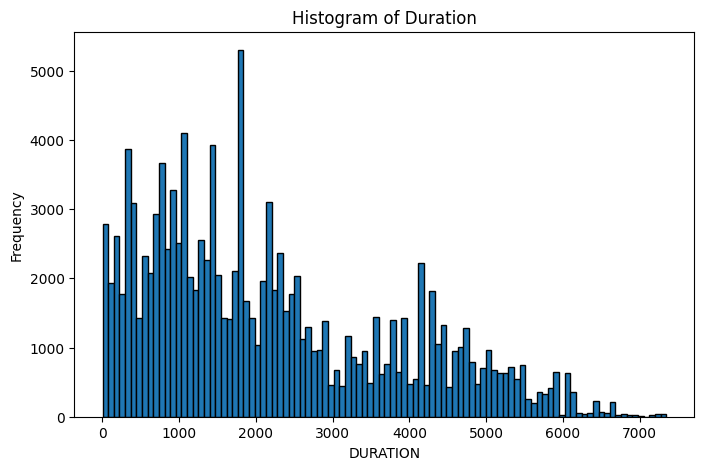

In [37]:
import matplotlib.pyplot as plt

# assuming df is your DataFrame
plt.figure(figsize=(8,5))
plt.hist(df["DURATION"], bins=100, edgecolor="black")
plt.xlabel("DURATION")
plt.ylabel("Frequency")
plt.title("Histogram of Duration")
plt.show()

In [38]:
df.Weather_failed.value_counts()

Weather_failed
0    124286
1       560
Name: count, dtype: int64

In [39]:
df['SECTION'].value_counts()

SECTION
PRYJ-CNBI                    9381
MTJ-OKA                      8940
KRJ-GZB                      7061
PNK--ETW                     5724
CAR - COI                    5528
                             ... 
JAB(W line AF) -BXN            12
GWL SOE                        12
AGD - MAKR CHORD LINE          10
LINK Jn NYN                     7
AGC-BKI connectivity line       1
Name: count, Length: 81, dtype: int64

In [40]:
df['LINE'].value_counts()

LINE
DN            41647
UP            40123
SL            30720
IIIRD LINE     9066
IVTH LINE      2374
OML             379
N               261
S               255
CHORD LINE       10
IIIrd Line        8
IVth Line         3
Name: count, dtype: int64

In [41]:
def reduce_line(line):
    if line in ["DN","DN 1", "DN 2"]:
        return "DN"
    elif line in ["SL", "IIIrd Line", "IVth Line", "MID"]:
        return "SL"
    elif line in ["UP 1", "UP 2","UP"]:
        return "UP"
    else:
        return "OT"

df["LINE"] = df["LINE"].apply(reduce_line)
df["LINE"].value_counts()


LINE
DN    41647
UP    40123
SL    30731
OT    12345
Name: count, dtype: int64

In [42]:
df =df[df['RAIL_SECTION']!= 'OTHER']

In [43]:
df.RAIL_SECTION.value_counts()

RAIL_SECTION
60KG    104306
52KG     20489
Name: count, dtype: int64

In [44]:
df['USFD_CLASSIFICATION'].value_counts()

USFD_CLASSIFICATION
GR                   124773
OBS Joggled Plate        22
Name: count, dtype: int64

In [45]:

#Replace values to standardize categories
df['USFD_CLASSIFICATION'] = df['USFD_CLASSIFICATION'].replace({
    'DFWR(JP)': 'DFW',
    'DFWO(JP)': 'DFW',
    'DFWO': 'DFW',
    'DFW(JP)': 'DFW',
    'DFWR': 'DFW',
    'DFWO Joggled Plate': 'DFW',
    'DFWR Joggled Plate': 'DFW',
    'OBS(W)(JP)': 'OBS',
    'OBS(W) Joggled Plate': 'OBS',
    'OBS(W)': 'OBS',
    'DFWN' : 'DFW',
'DFW Joggled Plate' : 'DFW' 
    
    
})


In [46]:
df['USFD_CLASSIFICATION'].value_counts()

USFD_CLASSIFICATION
GR                   124773
OBS Joggled Plate        22
Name: count, dtype: int64

In [47]:
df['USFD_CLASSIFICATION'].unique()

array(['GR', 'OBS Joggled Plate'], dtype=object)

In [48]:
import numpy as np
import re

def clean_axle_load(x):
    if pd.isna(x):
        return np.nan
    
    # Convert to string
    x = str(x).strip()
    
    # Handle ranges like "Up to 20.32"
    if "up to" in x.lower():
        num = re.findall(r"\d+\.?\d*", x)
        return int(round(float(num[0]))) if num else np.nan
    
    # Extract numeric part
    num = re.findall(r"\d+\.?\d*", x)
    if num:
        return int(round(float(num[0])))
    
    return np.nan


df["AXLELOAD"] = df["AXLELOAD"].apply(clean_axle_load)

df['AXLELOAD'].value_counts()

AXLELOAD
22    83865
23    40930
Name: count, dtype: int64

In [49]:

df['RAIL_SECTION'] = df['RAIL_SECTION'].str.replace('KG', '', regex=False).astype(int)

In [50]:
df['RAIL_SECTION'].value_counts()

RAIL_SECTION
60    104306
52     20489
Name: count, dtype: int64

Encoding 

In [51]:
import torch
import torch.nn as nn
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# Identify all object dtype columns
cat_cols = df.select_dtypes(include='object').columns.tolist()
print("Categorical columns:", cat_cols)


Categorical columns: ['RLYCODE', 'DIVCODE', 'SECTION', 'LINE', 'LRRR', 'TRACK_TYPE', 'STRAIGHT_CURVE', 'LAYINGDATE.1', 'USFD_CLASSIFICATION', 'Censoring_date', 'FRACTURE_DATE.1']


In [52]:
p95 = df['DURATION'].quantile(0.99)
print("95th Percentile:", p95)

95th Percentile: 6124.0


In [53]:
pd.set_option('display.max_columns', None)
df.isnull().sum().to_frame('Null Count').T

,RLYCODE,DIVCODE,SECTION,LINE,RAIL_SECTION,ANNUAL_GMT,SPEED,GMTCARRIED,LRRR,AXLELOAD,TRACK_TYPE,STRAIGHT_CURVE,SERVICE_LIFE,LAYINGDATE.1,USFD_CLASSIFICATION,KMTO,METTO,DURATION,Weather_failed,Censoring_date,FRACTURE_DATE.1
Null Count,0,0,0,0,0,21,0,5,0,0,0,0,0,0,0,0,0,0,0,559,124236


***Modeling***

In [54]:
import torch # For building the networks 
import torchtuples as tt # Some useful functions

In [55]:


# Step 2: Convert dates to datetime
df['FRACTURE_DATE.1'] = pd.to_datetime(df['FRACTURE_DATE.1'], errors='coerce')
df['LAYINGDATE.1'] = pd.to_datetime(df['LAYINGDATE.1'], errors='coerce')

# Step 3: Split failed and censored
df_failed = df[df['Weather_failed'] == 1]
df_censored = df[df['Weather_failed'] == 0]

# Step 4: Take latest FAILURE per ID
df_failed_last = df_failed.sort_values('FRACTURE_DATE.1')

# Step 5: Take latest CENSORING per ID
df_censored_last = df_censored.sort_values('LAYINGDATE.1')

# Step 6: Combine
df= pd.concat([df_failed_last, df_censored_last])

# Step 7: Safety check

print("Total rows:", len(df))

Total rows: 124795


In [56]:
df.shape

(124795, 21)

In [57]:
df

,RLYCODE,DIVCODE,SECTION,LINE,RAIL_SECTION,ANNUAL_GMT,SPEED,GMTCARRIED,LRRR,AXLELOAD,TRACK_TYPE,STRAIGHT_CURVE,SERVICE_LIFE,LAYINGDATE.1,USFD_CLASSIFICATION,KMTO,METTO,DURATION,Weather_failed,Censoring_date,FRACTURE_DATE.1
2712926,NCR,AGRA,AGC-RKM,DN,60,61.210,160.0,188.27,LR,23,LWR,STRAIGHT,800,2012-01-07,GR,1344,805.00,1105.0,1,NaN,2015-01-16
2713657,NCR,AGRA,MTJ-AWR,SL,60,23.230,110.0,65.67,LR,23,LWR,STRAIGHT,800,2010-01-04,GR,1494,131.00,1880.0,1,NaN,2015-02-27
2714140,NCR,AGRA,MTJ-AWR,SL,60,23.230,110.0,71.04,LR,23,LWR,CURVE,800,2009-01-02,GR,1488,341.00,2498.0,1,NaN,2015-11-05
2710662,NCR,JHS,JHS GWL,UP,60,61.780,130.0,102.74,LR,22,LWR,CURVE,800,2014-03-19,GR,1211,2315.00,610.0,1,NaN,2015-11-19
2716172,NCR,JHS,JHS GWL,DN,60,72.960,130.0,862.49,LR,22,SWR,STRAIGHT,800,2004-01-03,GR,1192,891.00,4359.0,1,NaN,2015-12-10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
709048,NCR,PRYJ,PNK--ETW,DN,60,43.945,130.0,4.00,RR,22,LWR,STRAIGHT,800,2025-10-01,GR,1153,618.86,7.0,0,2025-10-08,NaT
709047,NCR,PRYJ,PNK--ETW,DN,60,43.945,130.0,4.00,RR,22,LWR,STRAIGHT,800,2025-10-01,GR,1153,99.12,7.0,0,2025-10-08,NaT
709046,NCR,PRYJ,PNK--ETW,DN,60,43.945,130.0,4.00,RR,22,LWR,CURVE,800,2025-10-01,GR,1152,579.38,7.0,0,2025-10-08,NaT
709049,NCR,PRYJ,PNK--ETW,DN,60,43.945,130.0,4.00,RR,22,LWR,STRAIGHT,800,2025-10-01,GR,1154,197.57,7.0,0,2025-10-08,NaT


In [58]:
df['NEW_GMT'] = (df['DURATION']/365)*df['ANNUAL_GMT']
rail_map = { 52: 1,60: 2}
df["RAIL_SECTION"] = df["RAIL_SECTION"].map(rail_map)

# df["GMT_NO"] = df["GMT_CARRIED"] /df["ANNUAL_GMT"]
df["ANNUAL_LOAD"] = df["ANNUAL_GMT"] * df["AXLELOAD"]
df["AXLELOAD"]  = df["AXLELOAD"].map({22: 1, 23:2})
df["SPEED_AGMT"] = df["SPEED"] * df["ANNUAL_GMT"]


In [59]:
df = df.drop(columns=['LAYINGDATE.1', 'Censoring_date', 'FRACTURE_DATE.1', 'ANNUAL_GMT'])
df.sample(5)

,RLYCODE,DIVCODE,SECTION,LINE,RAIL_SECTION,SPEED,GMTCARRIED,LRRR,AXLELOAD,TRACK_TYPE,STRAIGHT_CURVE,SERVICE_LIFE,USFD_CLASSIFICATION,KMTO,METTO,DURATION,Weather_failed,NEW_GMT,ANNUAL_LOAD,SPEED_AGMT
687476,NCR,PRYJ,DDU-CAR,DN,2,130.0,300.0,LR,1,LWR,CURVE,1000,GR,701,860.0,2199.0,0,313.523178,1144.88,6765.2
664964,NCR,JHS,LAR JHS,OT,2,130.0,68.0,LR,1,LWR,CURVE,800,GR,1067,147.0,1376.0,0,67.857534,396.00,2340.0
640290,NCR,JHS,AIT BZM,UP,2,110.0,80.0,RR,1,SWR,STRAIGHT,800,GR,1322,787.5,1195.0,0,97.236986,653.40,3267.0
704064,NCR,PRYJ,MKP LINK JN,UP,2,110.0,124.0,RR,1,LWR,STRAIGHT,800,GR,1283,966.0,1376.0,0,143.556384,837.76,4188.8
716467,NCR,PRYJ,PRYJ-CNBI,DN,2,130.0,304.0,RR,1,LWR,CURVE,1000,GR,985,42.1,2503.0,0,359.951973,1154.78,6823.7


In [60]:
df= df[df.DURATION >0]

In [61]:
df.dropna(inplace= True)

In [62]:
df.shape

(124774, 20)

## 1. Feature Engineering & Train/Test Split

In [63]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# ── Encode remaining categoricals ──────────────────────────────────────────
cat_cols = df.select_dtypes(include='object').columns.tolist()
print("Categorical cols to encode:", cat_cols)

le_dict = {}
for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    le_dict[col] = le

# ── Target arrays ───────────────────────────────────────────────────────────
durations = df['DURATION'].values.astype(np.float32)
events    = df['Weather_failed'].values.astype(np.float32)

# ── Feature matrix ──────────────────────────────────────────────────────────
drop_cols = ['DURATION', 'Weather_failed']
X = df.drop(columns=drop_cols, errors='ignore').values.astype(np.float32)

scaler = StandardScaler()
X = scaler.fit_transform(X)

# ── Train / Val / Test split  (70 / 15 / 15) ────────────────────────────────
idx = np.arange(len(X))
idx_tv, idx_test = train_test_split(idx, test_size=0.15, random_state=42)
idx_train, idx_val = train_test_split(idx_tv, test_size=0.15/0.85, random_state=42)

X_train, X_val, X_test = X[idx_train], X[idx_val], X[idx_test]
dur_train, dur_val, dur_test = durations[idx_train], durations[idx_val], durations[idx_test]
ev_train,  ev_val,  ev_test  = events[idx_train],   events[idx_val],   events[idx_test]

print(f"Train: {len(X_train)}  Val: {len(X_val)}  Test: {len(X_test)}")
print(f"Event rate - Train: {ev_train.mean():.3f}  Test: {ev_test.mean():.3f}")


Categorical cols to encode: ['RLYCODE', 'DIVCODE', 'SECTION', 'LINE', 'LRRR', 'TRACK_TYPE', 'STRAIGHT_CURVE', 'USFD_CLASSIFICATION']
Train: 87341  Val: 18716  Test: 18717
Event rate - Train: 0.005  Test: 0.004


## 2. Install pycox (DeepSurv + DeepHit framework)

In [64]:
# Install pycox if not already available
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", "pycox", "--quiet"], check=True)
import pycox
print("pycox version:", pycox.__version__)


pycox version: 0.3.0


## 3. DeepSurv

In [65]:
import torch
import torchtuples as tt
from pycox.models import CoxPH
from pycox.evaluation import EvalSurv
import numpy as np

# ── Helpers ─────────────────────────────────────────────────────────────────
def get_target(durations, events):
    return (durations.astype(np.float32), events.astype(np.float32))

in_features = X_train.shape[1]

# ── Architecture ─────────────────────────────────────────────────────────────
net_ds = torch.nn.Sequential(
    torch.nn.Linear(in_features, 256),
    torch.nn.BatchNorm1d(256),
    torch.nn.ReLU(),
    torch.nn.Dropout(0.3),
    torch.nn.Linear(256, 128),
    torch.nn.BatchNorm1d(128),
    torch.nn.ReLU(),
    torch.nn.Dropout(0.3),
    torch.nn.Linear(128, 64),
    torch.nn.ReLU(),
    torch.nn.Linear(64, 1)
)

model_ds = CoxPH(net_ds, tt.optim.Adam)

# ── Callbacks ────────────────────────────────────────────────────────────────
callbacks = [tt.callbacks.EarlyStopping(patience=10)]

# ── Training ─────────────────────────────────────────────────────────────────
batch_size = 256
epochs     = 100
lrfinder   = model_ds.lr_finder(
    X_train, get_target(dur_train, ev_train),
    batch_size=batch_size, tolerance=3
)
best_lr = lrfinder.get_best_lr()
print(f"Best LR (DeepSurv): {best_lr:.6f}")

model_ds.optimizer.set_lr(best_lr)

log_ds = model_ds.fit(
    X_train, get_target(dur_train, ev_train),
    batch_size=batch_size,
    epochs=epochs,
    callbacks=callbacks,
    verbose=True,
    val_data=(X_val, get_target(dur_val, ev_val))
)
print("Training complete.")


Best LR (DeepSurv): 0.000100
0:	[2s / 2s],	
1:	[2s / 5s],	
2:	[2s / 7s],	
3:	[3s / 10s],	
4:	[2s / 13s],	
5:	[2s / 15s],	
6:	[2s / 17s],	
7:	[2s / 20s],	
8:	[2s / 22s],	
9:	[2s / 24s],	
Training complete.


In [66]:
# ── Fix scipy.integrate.simps for pycox compatibility ────────────────────────
import scipy.integrate
import numpy as np

_orig_simpson = scipy.integrate.simpson

def _simps_compat(y, x=None, *args, **kwargs):
    if x is not None:
        return _orig_simpson(y, x=x)
    return _orig_simpson(y)

scipy.integrate.simps = _simps_compat

# Also patch the already-imported reference inside pycox.evaluation.ipcw
import pycox.evaluation.ipcw as _ipcw_mod
_ipcw_mod.scipy.integrate.simps = _simps_compat

print("simps patch applied to pycox.evaluation.ipcw ✓")

simps patch applied to pycox.evaluation.ipcw ✓


## 4. DeepHit

In [67]:
from pycox.models import DeepHitSingle
import torchtuples as tt
import numpy as np

# ── Discretise time ──────────────────────────────────────────────────────────
num_durations = 100
labtrans = DeepHitSingle.label_transform(num_durations)

target_train = labtrans.fit_transform(*get_target(dur_train, ev_train))
target_val   = labtrans.transform(*get_target(dur_val,   ev_val))

# ── Architecture ─────────────────────────────────────────────────────────────
in_features = X_train.shape[1]
out_features = labtrans.out_features   # = num_durations

net_dh = torch.nn.Sequential(
    torch.nn.Linear(in_features, 256),
    torch.nn.BatchNorm1d(256),
    torch.nn.ReLU(),
    torch.nn.Dropout(0.3),
    torch.nn.Linear(256, 128),
    torch.nn.BatchNorm1d(128),
    torch.nn.ReLU(),
    torch.nn.Dropout(0.3),
    torch.nn.Linear(128, 64),
    torch.nn.ReLU(),
    torch.nn.Linear(64, out_features)
)

model_dh = DeepHitSingle(net_dh, tt.optim.Adam,
                          alpha=0.2, sigma=0.1,
                          duration_index=labtrans.cuts)

# ── LR finder ────────────────────────────────────────────────────────────────
lrfinder_dh = model_dh.lr_finder(
    X_train, target_train,
    batch_size=256, tolerance=3
)
best_lr_dh = lrfinder_dh.get_best_lr()
print(f"Best LR (DeepHit): {best_lr_dh:.6f}")
model_dh.optimizer.set_lr(best_lr_dh)

callbacks_dh = [tt.callbacks.EarlyStopping(patience=10)]

log_dh = model_dh.fit(
    X_train, target_train,
    batch_size=256,
    epochs=100,
    callbacks=callbacks_dh,
    verbose=True,
    val_data=(X_val, target_val)
)
print("Training complete.")


Best LR (DeepHit): 0.035112
0:	[5s / 5s],		train_loss: 0.0126,	val_loss: 0.0133
1:	[4s / 10s],		train_loss: 0.0088,	val_loss: 0.0072
2:	[5s / 15s],		train_loss: 0.0082,	val_loss: 0.0065
3:	[4s / 20s],		train_loss: 0.0077,	val_loss: 0.0061
4:	[4s / 25s],		train_loss: 0.0079,	val_loss: 0.0099
5:	[5s / 30s],		train_loss: 0.0079,	val_loss: 0.0068
6:	[5s / 35s],		train_loss: 0.0077,	val_loss: 0.0062
7:	[4s / 40s],		train_loss: 0.0079,	val_loss: 0.0064
8:	[4s / 45s],		train_loss: 0.0079,	val_loss: 0.0063
9:	[5s / 50s],		train_loss: 0.0074,	val_loss: 0.0066
10:	[4s / 55s],		train_loss: 0.0074,	val_loss: 0.0065
11:	[5s / 1m:1s],		train_loss: 0.0075,	val_loss: 0.0062
12:	[4s / 1m:6s],		train_loss: 0.0073,	val_loss: 0.0075
13:	[4s / 1m:10s],		train_loss: 0.0078,	val_loss: 0.0065
Training complete.


In [68]:
# ── Evaluate DeepHit ─────────────────────────────────────────────────────────
surv_dh_test = model_dh.predict_surv_df(X_test)

ev_dh = EvalSurv(surv_dh_test,
                 dur_test.astype(np.float64),
                 ev_test.astype(np.int32),
                 censor_surv='km')

c_idx_dh = ev_dh.concordance_td()

time_grid_dh = np.linspace(dur_test.min(), dur_test.max(), 100)
ibs_dh = ev_dh.integrated_brier_score(time_grid_dh)

# RMSE on failed events
mask_ev = ev_test == 1   # ← redefined here
median_surv_dh = surv_dh_test.apply(lambda col: col[col <= 0.5].index[0]
                                    if (col <= 0.5).any()
                                    else surv_dh_test.index[-1])
rmse_dh = np.sqrt(np.mean((median_surv_dh.values[mask_ev] - dur_test[mask_ev])**2))

print("=" * 45)
print("         DeepHit Results (Test Set)")
print("=" * 45)
print(f"  C-index  : {c_idx_dh:.4f}")
print(f"  IBS      : {ibs_dh:.4f}")
print(f"  RMSE     : {rmse_dh:.4f}  (on failed events)")
print("=" * 45)

         DeepHit Results (Test Set)
  C-index  : 0.9101
  IBS      : 0.0096
  RMSE     : 4039.5703  (on failed events)


## 6. Survival Curves (Sample Predictions)

NameError: name 'surv_ds_test' is not defined

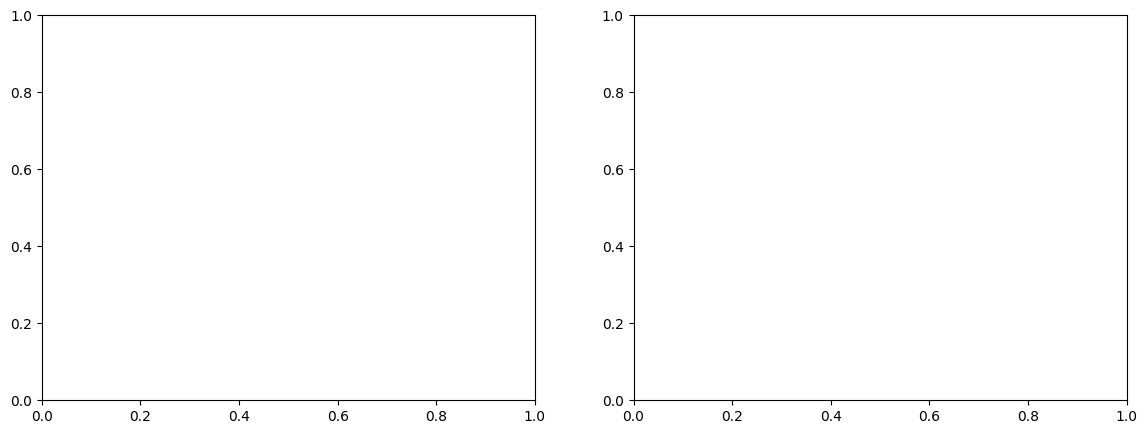

In [69]:
import matplotlib.pyplot as plt

# Pick 3 random test samples
np.random.seed(42)
sample_idx = np.random.choice(np.where(ev_test == 1)[0], size=3, replace=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# DeepSurv
ax = axes[0]
for i, idx_ in enumerate(sample_idx):
    ax.plot(surv_ds_test.index, surv_ds_test.iloc[:, idx_],
            label=f"Sample {i+1} (dur={dur_test[idx_]:.0f}d)")
ax.axhline(0.5, color='grey', linestyle='--', linewidth=0.8, label='S=0.5')
ax.set_title('DeepSurv – Survival Functions')
ax.set_xlabel('Duration (days)')
ax.set_ylabel('Survival Probability')
ax.legend()
ax.grid(True, alpha=0.3)

# DeepHit
ax = axes[1]
for i, idx_ in enumerate(sample_idx):
    ax.plot(surv_dh_test.index, surv_dh_test.iloc[:, idx_],
            label=f"Sample {i+1} (dur={dur_test[idx_]:.0f}d)")
ax.axhline(0.5, color='grey', linestyle='--', linewidth=0.8, label='S=0.5')
ax.set_title('DeepHit – Survival Functions')
ax.set_xlabel('Duration (days)')
ax.set_ylabel('Survival Probability')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('survival_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved.")


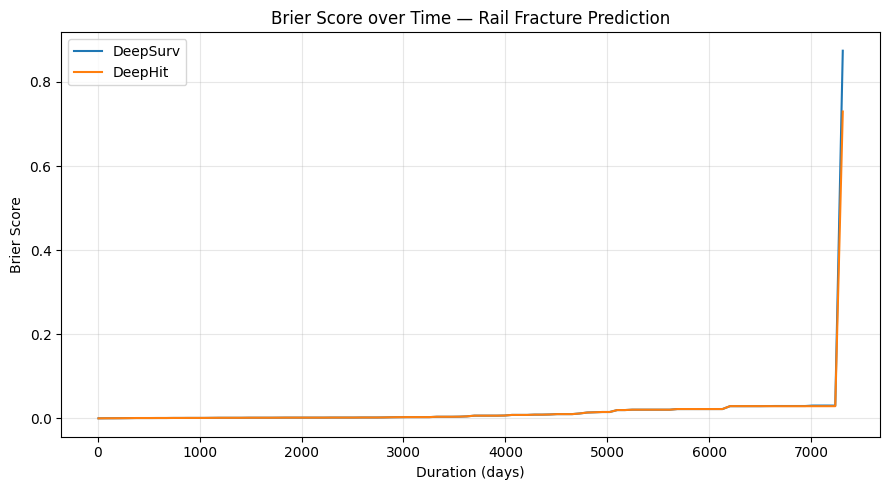

Brier score plot saved.


In [ ]:
# Brier Score over time
fig, ax = plt.subplots(figsize=(9, 5))

bs_ds = ev_ds.brier_score(time_grid_ds)
bs_dh = ev_dh.brier_score(time_grid_dh)

ax.plot(time_grid_ds, bs_ds, label='DeepSurv')
ax.plot(time_grid_dh, bs_dh, label='DeepHit')
ax.set_xlabel('Duration (days)')
ax.set_ylabel('Brier Score')
ax.set_title('Brier Score over Time — Rail Fracture Prediction')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('brier_score_time.png', dpi=150, bbox_inches='tight')
plt.show()
print("Brier score plot saved.")


## 7. Save Model Weights

In [ ]:
import torch

torch.save(net_ds.state_dict(), 'deepsurv_weights.pt')
torch.save(net_dh.state_dict(), 'deephit_weights.pt')
print("Weights saved: deepsurv_weights.pt  |  deephit_weights.pt")


Weights saved: deepsurv_weights.pt  |  deephit_weights.pt


## Summary

| Metric  | DeepSurv | DeepHit |
|---------|----------|---------|
| **C-index** | — | — |
| **IBS**     | — | — |
| **RMSE**    | — | — |

> Fill in the values from cell outputs above. Higher C-index = better discrimination. Lower IBS/RMSE = better calibration/prediction accuracy.

### Interpretation
- **DeepSurv** extends Cox PH with a deep neural network for the log-risk score — retains proportional hazards assumption.
- **DeepHit** models the joint distribution of survival time and event directly; more flexible, no PH assumption.
- **RMSE** is computed on failed events only (median survival time vs actual duration).
- **IBS** (Integrated Brier Score) measures calibration across the full time horizon.
